IA & Data science (LU3IN0226) -- 2025-2026
--------
*&copy; Equipe pédagogique: Christophe Marsala, Olivier Schwander, Jean-Noël Vittaut, Maxellende Julienne.*


# TD-TME11: méthodes d'ensembles

L'objectif de ce notebook est d'implémenter des méthodes d'ensembles et de les évaluer. Dans un premier temps, on se focalise sur l'algorithme de bagging appliqué aux arbres de décision.

<font color="RED" size="+1">**[Q]**</font> **Indiquer dans la boîte ci-dessous vos noms et prénoms :**

*Double-cliquer ici et insérer les noms et prénoms de votre binôme*

<font color="RED" size="+1"><b>[Q]</b></font> **Renommer ce notebook**

Tout en haut de cette page, cliquer sur <tt>tme-11</tt> et rajouter à la suite de <tt>tme-10</tt> les noms des membres du binômes séparés par un tiret.

<font color="RED" size="+1">IMPORTANT: fichier final</font>

**Nom à donner au fichier à poster** : *tme-11-Nom1_Nom2.ipynb* 
- *Nom1* et *Nom2* : noms des membres du binôme
- ne pas compresser ou faire une archive: il faut rendre le notebook tel quel, éventuellement, si vous avez d'autres fichiers vous les rendez séparément.

**Echancier pour la soumission de votre compte-rendu:**
- Ce TME ne donne pas lieu à un compte-rendu.



In [1]:
# - - - - - - - - - - - - - - - - - -
# imports utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mtpl
%matplotlib inline  

import math
import time
import sys

# Les instructions suivantes sont utiles pour recharger automatiquement 
# le code modifié dans les librairies externes
%load_ext autoreload
%autoreload 2

# - - - - - - - - - - - - - - - - - -
# Information sur l'environnent utilisé ici:
print("Version python et des librairies:")
print("\tPython ",sys.version)
print("\tpandas: ",pd.__version__)
print("\tnumpy: ",np.__version__)
print("\tmatplotlib: ",mtpl.__version__)

Version python et des librairies:
	Python  3.14.3 (main, Feb  3 2026, 15:32:20) [Clang 17.0.0 (clang-1700.6.3.2)]
	pandas:  3.0.3
	numpy:  2.4.4
	matplotlib:  3.10.9


In [6]:
# Importation de votre librairie iads:
# La ligne suivante permet de préciser le chemin d'accès à la librairie iads
sys.path.append('../')   # iads doit être dans le répertoire père du répertoire courant !

# Importation de la librairie iads
import iads as iads

# importation de Classifiers
from iads import Classifiers as cl

# importation de utils
from iads import utils as ut

# importation de evaluation
from iads import evaluation as ev

# importation de Clustering
from iads import Clustering as clust

from iads import Arbres_decision as ar


## Préparation : retour sur les arbres de décision

### Création d'un dataset pour tester les fonctions

Taille du dataset généré : (200, 2) exemples


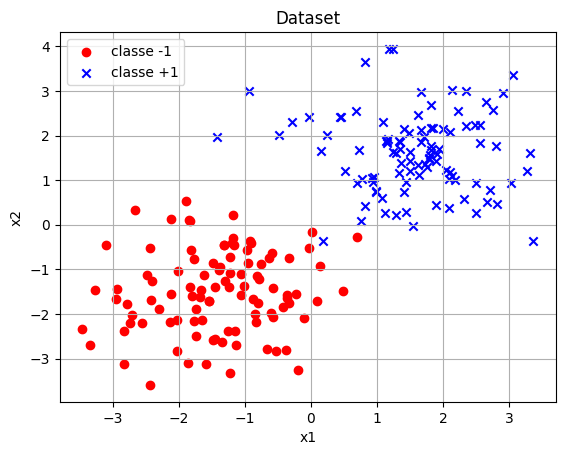

In [4]:
np.random.seed(2026)   # on prend 2026 comme graine (pour changer)

# Générer un dataset gaussien pour expérimenter
positive_center = np.array([1.5, 1.5])
negative_center = np.array([-1.5, -1.5])
positive_sigma  = np.array([[0.8, 0.0], [0.0, 0.8]])
negative_sigma  = np.array([[0.8, 0.0], [0.0, 0.8]])
nc = 100
d_desc_gauss, d_label_gauss = ut.genere_dataset_gaussian(positive_center, positive_sigma, negative_center, negative_sigma, nc)

print("Taille du dataset généré :", np.shape(d_desc_gauss), "exemples")
# Affichage :
ut.plot2DSet(d_desc_gauss,d_label_gauss)



### Frontière de séparation des classes 

<font color="RED" size="+1"><b>[Q]</b></font> En utilisant vos fonctions de construction des arbres numériques du TME 8, afficher la frontière de séparation des classes et l'arbre obtenu pour les données générées.

Accuracy (train):  1.0


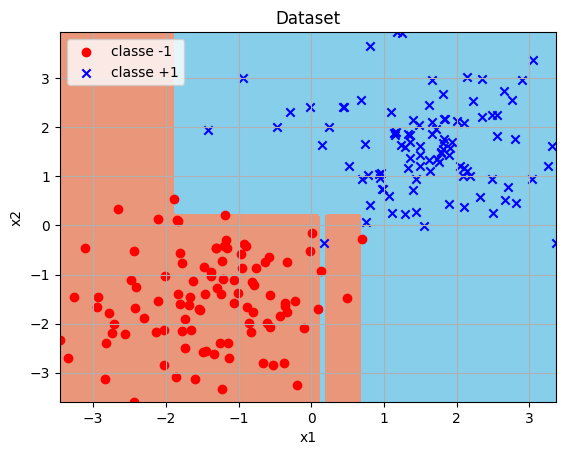

In [7]:
# De même, les classes de Classifiers sont utilisables en mettant classif. devant leur nom:
# Création d'un perceptron
arbre_1 = ar.ClassifierArbreGeneral(2, 0.0)

# Construction de l'arbre de décision à partir du dataset généré plus haut
arbre_1.train(d_desc_gauss,d_label_gauss)
print("Accuracy (train): ", arbre_1.accuracy(d_desc_gauss,d_label_gauss))

# Affichage de la frontière de séparation des classes
ut.plot_frontiere(d_desc_gauss,d_label_gauss,arbre_1,step=120)
ut.plot2DSet(d_desc_gauss,d_label_gauss)

<font color="RED" size="+1"><b>[Q]</b></font> Afficher l'arbre construit.

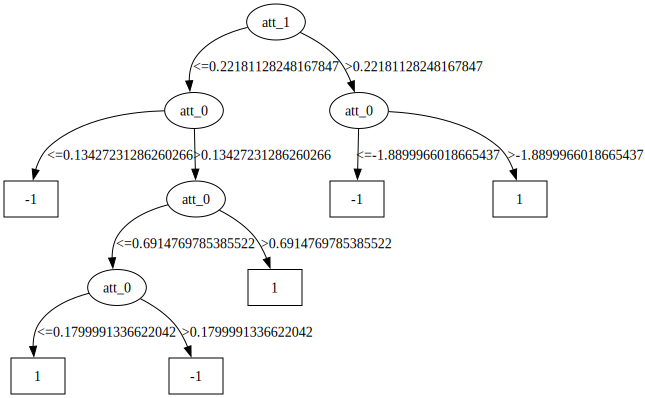

In [8]:
import graphviz as gv

# Construction de la représentation graphique (affichage)
graphe_arbre_1 = gv.Digraph(format='png')
arbre_1.affiche(graphe_arbre_1)

# Affichage du graphe obtenu:
graphe_arbre_1

<font color="RED" size="+1"><b>[Q]</b></font> Sur une feuille de papier, représenter la frontière de séparation des classes en la dessinant à la main et en utilisant l'arbre ci-dessus.

Même chose mais en utilisant un seuil d'entropie lors de la construction, ici égal à $0.55$ 


Accuracy (train):  0.97


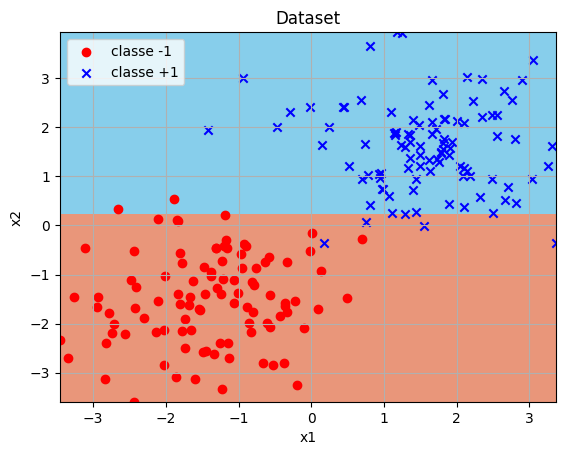

In [10]:
# De même, les classes de Classifiers sont utilisables en mettant classif. devant leur nom:
# Création d'un perceptron
arbre_2 = ar.ClassifierArbreNumerique(2, 0.55)

# Construction de l'arbre de décision à partir du dataset généré plus haut
arbre_2.train(d_desc_gauss,d_label_gauss)
print("Accuracy (train): ", arbre_2.accuracy(d_desc_gauss,d_label_gauss))

# Affichage de la frontière de séparation des classes
ut.plot_frontiere(d_desc_gauss,d_label_gauss,arbre_2,step=120)
ut.plot2DSet(d_desc_gauss,d_label_gauss)



## Bagging d'arbres de décision

### Tirage aléatoire d'exemples

Le bootstrap s'effectue en tirant aléatoirement un échantillon de $m$ exemples à partir de la base d'apprentissage $X$. Cet échantillon sert ensuite à construire un classifieur.

Dans l'algorithme du bagging, ce processus est répété $B$ fois.

Afin de ne pas alourdir la place mémoire nécessaire pour réaliser un tel tirage, on ne travaille que sur les indices des exemples dans la base. Un **échantillon de $X$ est donc un vecteur d'entiers** qui représentent les indices des exemples choisis.


### Tirages aléatoires

Consulter la librairie Python random qui propose différentes fonctions utiles pour implémenter le tirage aléatoire du bootstrap.

Par exemple, la fonction <code>sample()</code> de la librairie <code>random</code> rend une sélection aléatoire dans une population donnée en réalisant un tirage sans remise.

Pour tester, exécuter plusieurs fois les instructions de la boîte suivante :

In [11]:
import random
random.seed(2026)   # on prend 2026 comme graine (pour le générateur random cette fois)

L= [i for i in range(0,11)]             # construction de la liste des entiers de 0 à 10
print("La liste L de départ: ",L)
EchL = random.sample(L,6)               # tirage de 6 éléments de L
print("Echantillon: ",EchL)


La liste L de départ:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Echantillon:  [1, 5, 8, 10, 7, 4]


La fonction <code>choice()</code> de la librairie <code>random</code> permet de choisir aléatoirement un élément dans une liste:

In [16]:
random.seed(2026)   # on prend 2026 comme graine

L= [i for i in range(0,11)]             # construction de la liste des entiers de 0 à 10
print("La liste L de départ: ",L)
elt = random.choice(L)                  # choix d'un élémént
print("Element choisi: ",elt)

La liste L de départ:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Element choisi:  1


<font color="RED" size="+1">**[Q]**</font> Ecrire la fonction <code>tirage()</code> qui étant donné un vecteur d'entiers <i>VX</i> qui représente l'ensemble des indices des exemples d'une base d'apprentissage <i>X</i>, un entier $m$, et un booléen $r$, rend un vecteur de $m$ indices choisis aléatoirement dans <i>VX</i>. Si le booléen $r$ est vrai, le tirage s'effectue *avec remise*, sinon il s'effectue *sans remise*.

In [25]:
import random

# ############################################## A COMPLETER 

def tirage(VX, m, avecRemise=False):
    """ VX: vecteur d'indices 
        m : nombre d'exemples à sélectionner (hypothèse: m <= len(VX))
        avecRemise: booléen, true si avec remise, ou faux sinon
    """
    if not avecRemise: 
        return random.sample(VX,m) 
    else: 
        return np.random.choice(VX, size=m, replace=True)


Exemples :

In [30]:
random.seed(2026)   # on prend 2026 comme graine
L= [i for i in range(0,10)]    # construction de la liste des entiers de 0 à 100
Lrand = tirage(L,8,True)               # tirage avec remise
print("Tirage obtenu: ",Lrand)
# Choix de lignes quelconques de d_desc
d_desc_gauss[Lrand,:]

Tirage obtenu:  [7 6 1 5 9 9 2 5]


array([[-1.45274709, -2.55935249],
       [-0.19418514, -3.25493954],
       [-0.42706727, -1.84781392],
       [-0.92988528, -0.36763019],
       [-2.66379377,  0.32902373],
       [-2.66379377,  0.32902373],
       [-1.8065377 , -1.60824244],
       [-0.92988528, -0.36763019]])

Dans ce qui suit, pour faciliter les énoncés, on appelle <code>LabeledSet</code> un couple de 2 np.arrays $X$ pour les descriptions des exemples et $Y$ pour les labels correspondant à chaque exemple.

Par exemple, le <code>LabeledSet</code> pour les données générées précédemment est <code>(d_des_gauss,d_label_gauss)</code>.

<font color="RED" size="+1">**[Q]**</font> En utilisant la fonction précédente, écrire la fonction <code>echantillonLS()</code> qui, étant donné un <code>LabeledSet</code> $LS$, un nombre entier $m$, et un booléen $r$ (avec ou sans remise) rend le <code>LabeledSet</code> échantillon de $LS$ de taille $m$. 

*Remarque*: on peut faire l'hypothèse que $m$ est inférieur ou égal au nombre de lignes de $LS$. 


In [41]:
# ############################################## A COMPLETER 
def echantillonLS(LS,m,avecRemise):
    """ LS: LabeledSet (couple de np.arrays)
        m : entier donnant la taille de l'échantillon voulu (hypothèse: m <= len(LS))
        avecRemise: booléen pour le mode de tirage
    """
    (desc, labels) = LS
    v_indices = np.arange(desc.shape[0])
    tirage_index = tirage(v_indices, m, avecRemise)
    return (desc[tirage_index], labels[tirage_index])
        

In [42]:
echantillonLS((d_desc_gauss,d_label_gauss),10,True)

(array([[-0.85392524, -1.99075327],
        [ 2.49116952,  0.94179109],
        [-0.5305953 , -2.8387926 ],
        [ 0.68470745,  2.55729534],
        [-0.81416143, -1.14471126],
        [-1.62224391, -1.12611783],
        [-1.22466499, -0.72908326],
        [ 0.69147698, -0.27735441],
        [-1.38614475, -1.01978878],
        [-1.42703486,  1.95590163]]),
 array([-1,  1, -1,  1, -1, -1, -1, -1, -1,  1]))

<font color="RED" size="+1">**[Q]**</font> Ecrire la classe <code>ClassifierBaggingTree</code>, dérivée de la classe <code>Classifier</code>, qui permet d'implémenter un bagging d'arbres de décision (numériques). Les spécifications de cette classe sont :
- la création de l'ensemble nécessite les paramètres suivants :
    - la dimension des données (comme pour les classifieurs précédents) 
    - le nombre $B$ d'arbres à construire, 
    - le pourcentage d'exemples de la base d'apprentissage utilisés pour constituer un échantillon, 
    - un booléen qui précise si un échantillon est tiré avec ou sans remise
    - et la valeur de seuil d'entropie pour arrêter la construction de chaque arbre, 
- l'apprentissage (méthode <code>train()</code>) construit autant d'arbres que précisé à la création. Chaque arbre est construit à partir d'un échantillon de la base d'apprentissage (donnée sous forme d'un <code>LabeledSet</code>) donnée en argument. Les arbres construits sont stockés dans un ensemble Python.
- le score de classification <code>score()</code> est une valeur de $[-1,1]$ qui est calculé sur le modèle du score des $k$ plus proches voisins, il est basé sur le pourcentage de classifieurs qui ont donné la classe $+1$ pour l'exemple à classer. 
- la prédiction (méthode <code>predict()</code>) classe un exemple par vote de tous les arbres de la forêt. Si la somme des votes est positive ou nulle, la classe rendue est +1, sinon, la classe rendue est -1. Cette prédiction peut aussi être déterminée par le score: si celui-ci est supérieur ou éval à $0$ alors la classe prédite sera +1, sinon elle sera -1.


In [ ]:
class ClassifierBaggingTree(cl.Classifier):
    def __init__(self, input_dimension, nbArbres, pourc, epsilon, avecRemise):
        """ int * float * float * bool -> ClassifierBaggingTree
            - input_dimension (int) : dimension de la description des exemples (>0)
            - nbArbres: nombre d'arbres de la forêt
            - pourc : pourcentage des exemples de la base pour échantillon
            - epsilon: paramètre d'arrêt des arbres (voir classe ArbreDecision)
            - avecRemise: booléen, tirage avec ou sans remise
        """
        super().__init__(input_dimension)  
        self.__nbArbres = nbArbres
        self.__pourc = pourc
        self.__avecRemise = avecRemise
        self.__epsilon = epsilon 
        self.__foret = []    
        self.__m = None      
             
    def __str__(self):
        """  -> str
            rend le nom du classifieur avec ses paramètres
        """
        return super().__str__() + ' - ClassifierBaggingTree eps=' + str(self.__epsilon) + ' nb_arbres=' + str(self.__nbArbres)

    def train(self, LS, verbose=False):
        """ LS: LabeledSet : the training set
            construit la forêt: on ajoute dans la forêt autant d'arbres que nécessaires
        """
        (desc, labels) = LS
        n_lig, n_col = desc.shape
        
        self.__m = int(self.__pourc * n_lig)
        if self.__m < 1:
            self.__m = 1  
            
        self.__foret = []
        
        for i in range(self.__nbArbres): 
            (d_desc, d_label) = echantillonLS(LS, self.__m, self.__avecRemise)
            arbre = ar.construit_AD_num(d_desc, d_label, self.__epsilon)
            self.__foret.append(arbre)
        
    def add_tree(self, LS):
        """ LS: LabeledSet : the training set
            Ajoute un nouvel arbre dans la forêt
        """
        (desc, labels) = LS
        n_lig, n_col = desc.shape
        
        if self.__m is None:
            self.__m = int(self.__pourc * n_lig)
            
        (d_desc, d_label) = echantillonLS(LS, self.__m, self.__avecRemise)
        arbre = ar.construit_AD_num(d_desc, d_label, self.__epsilon)
        self.__foret.append(arbre)
        self.__nbArbres += 1 
        
    def score(self, x):
        """ rend le score de prédiction sur x (valeur réelle)
            x: une description
        """
        if len(self.__foret) == 0:
            return 0.0
            
        total_votes = 0
        for arbre in self.__foret:
            vote = arbre.classifie(x)
            if vote is not None:
                total_votes += vote
                
        return total_votes
            
    def predict(self, x):
        """ x: un exemple
            rend le score (+1 ou -1) de classification de x via vote de majorité
        """
        total_score = self.score(x)
        if total_score >= 0:
            return 1
        else:
            return -1
        
        

Base d'apprentissage: (80, 2) et 80 labels
Base de test: (320, 2) et 320 labels


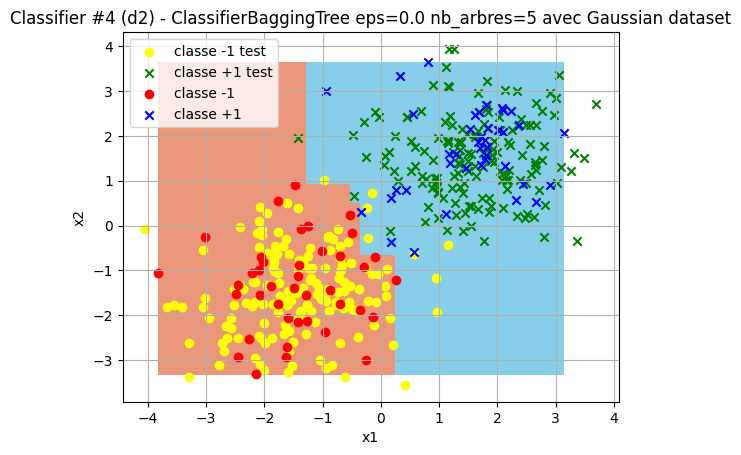

Accuracy Train:	1.0000
Accuracy Test:	0.9688

accuracy totale: 0.975


In [47]:
# Exemple d'utilisation:
np.random.seed(2026)   # on prend 2026 comme graine

# ################### A COMPLETER 

# Générer un dataset gaussien pour expérimenter
positive_center = np.array([1.5, 1.5])
negative_center = np.array([-1.5, -1.5])
positive_sigma  = np.array([[0.8, 0.0], [0.0, 0.8]])
negative_sigma  = np.array([[0.8, 0.0], [0.0, 0.8]])
nc = 200
X_gauss, Y_gauss = ut.genere_dataset_gaussian(positive_center, positive_sigma, negative_center, negative_sigma, nc)

# Découpage en train/test du dataset gaussien
(train_desc, train_label), (test_desc, test_label) = ut.genere_train_test(X_gauss, Y_gauss, 40, 40)

print(f"Base d'apprentissage: {train_desc.shape} et {len(train_label)} labels")
print(f"Base de test: {test_desc.shape} et {len(test_label)} labels")

# Forêt de 5 arbres:
foret_1 = ClassifierBaggingTree(2,5,0.8,0.0,True)
foret_1.train((train_desc, train_label))

# Affichage de la frontière de séparation des classes
ut.plot_frontiere(train_desc, train_label,foret_1,step=120)
ut.plot2DTrainTestSet(train_desc,train_label,test_desc,test_label, nom_dataset=f"{foret_1} avec Gaussian dataset")

print(f"Accuracy Train:\t{foret_1.accuracy(train_desc, train_label):1.4f}")
print(f"Accuracy Test:\t{foret_1.accuracy(test_desc, test_label):1.4f}")

print("\naccuracy totale:",foret_1.accuracy(d_desc_gauss,d_label_gauss))

### Expérimentations

<font color="RED" size="+1">**[Q]**</font> Expérimenter l'algorithme précédent de la façon suivante :
- générer une base d'apprentissage Data avec 1000 exemples ;
- générer une base de test $T$ contenant 200 exemples ;
- réaliser un apprentissage par bagging avec $Data$ et évaluer le taux de prédiction du modèle obtenu sur $T$ ;

**Remarque**: réinitialiser la graine aléatoire avant de construire une forêt.

In [51]:
# On initialise la graine
np.random.seed(2026)   # on prend 2026 comme graine
positive_center = np.array([0.8, 0.8])
negative_center = np.array([-0.8, -0.8])

positive_sigma  = np.array([[1.0, 0.0], [0.0, 1.0]])
negative_sigma  = np.array([[1.0, 0.0], [0.0, 1.0]])
nc_data = 1000
nc_test = 200

Data_desc, Data_label = ut.genere_dataset_gaussian(positive_center, positive_sigma, negative_center, negative_sigma, nc_data)
T_desc, T_label = ut.genere_dataset_gaussian(positive_center, positive_sigma, negative_center, negative_sigma, nc_test)

foret_1 = ClassifierBaggingTree(2,5,0.8,0.0,True)
foret_1.train((Data_desc, Data_label))

acc_train = foret_1.accuracy(Data_desc, Data_label)
acc_test  = foret_1.accuracy(T_desc, T_label)

print("="*50)
print(f"Taux de prédiction (Accuracy) sur Data (Train) : {acc_train * 100:.2f}%")
print(f"Taux de prédiction (Accuracy) sur T (Test)     : {acc_test * 100:.2f}%")
print("="*50)


Taux de prédiction (Accuracy) sur Data (Train) : 95.80%
Taux de prédiction (Accuracy) sur T (Test)     : 85.25%


<font color="RED" size="+1">**[Q]**</font> En utilisant le résultat précédent, construire la courbe donnant la variation du **taux d'erreur** en fonction du nombre d'arbres dans la forêt.


Calcul de la courbe d'erreur en fonction du nombre d'arbres...


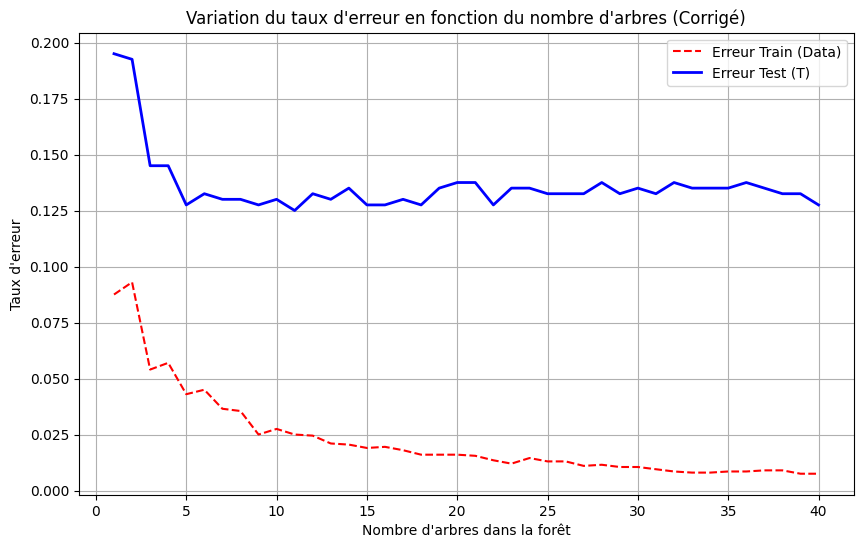

In [ ]:
import matplotlib.pyplot as plt
np.random.seed(42)
foret_courbe = ClassifierBaggingTree(input_dimension=2, nbArbres=0, pourc=0.8, epsilon=0.0, avecRemise=True)

erreurs_train = []
erreurs_test = []

print("Calcul de la courbe d'erreur en fonction du nombre d'arbres...")

for i in range(1, 41):
    foret_courbe.add_tree((Data_desc, Data_label))
    
    acc_tr = foret_courbe.accuracy(Data_desc, Data_label)
    acc_te = foret_courbe.accuracy(T_desc, T_label)
    
    erreurs_train.append(1.0 - acc_tr)
    erreurs_test.append(1.0 - acc_te)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 41), erreurs_train, label="Erreur Train (Data)", color="red", linestyle="--")
plt.plot(range(1, 41), erreurs_test, label="Erreur Test (T)", color="blue", linewidth=2)

plt.title("Variation du taux d'erreur en fonction du nombre d'arbres (Corrigé)")
plt.xlabel("Nombre d'arbres dans la forêt")
plt.ylabel("Taux d'erreur")
plt.grid(True)
plt.legend()
plt.show()


## Version multiclasses

<font color="RED" size="+1">**[Q]**</font> Réaliser une version multiclasses de cet algorithme en utilisant le  `ClassifierMultiOAA` du TME 4 (en l'adaptant si besoin) et l'expérimenter sur les données des Iris de Fischer (par exemple).



## (optionnel) Evaluation par la méthode "Out Of Bags"

<font color="RED" size="+1">**[Q]**</font> Sur les mêmes données, réaliser une évaluation par la méthode "Out Of Bags" vue dans le cours 11. Construire la courbe donnant le taux de prédiction OOB en fonction de la taille de la forêt d'arbres.

Pour cela, écrire la classe <code>ClassifierBaggingTreeOOB</code> qui étend la classe d'un classifieur bagging pour prendre en compte la spécificité de l'approche OOB.
Ainsi, à partir de $\mathcal{X}$, l'ensemble des données d'apprentissage, chaque arbre $A_i$ de la forêt est associé à 2 sous-ensembles de $\mathcal{X}$: 
- $\mathcal{X}_i$: l'échantillon bootstrap qui sert à construire l'arbre $A_i$
- $\mathcal{T}_i$: l'ensemble des exemples OOB associés à l'arbre $A_i$

Le calcul du taux de bonne classification s'effectuera comme suit:
- soit $t_i$ le taux de bonne classification de $A_i$ pour l'ensemble OOB $\mathcal{T}_i$
- le taux de global de bonne classification de la forêt d'arbres $A_1$,..., $A_B$ est donné par $\frac{1}{B}\sum_{i=1}^{B} t_i$


In [ ]:
class ClassifierBaggingTreeOOB(cl.Classifier):
    def __init__(self, input_dimension, nbArbres, pourc, epsilon, avecRemise):
        """ int * float * float * bool -> ClassifierBaggingTree
            - input_dimension (int) : dimension de la description des exemples (>0)
            - nbArbres: nombre d'arbres de la forêt
            - pourc : pourcentage des exemples de la base pour échantillon
            - epsilon: paramètre d'arrêt des arbres (voir classe ArbreDecision)
            - avecRemise: booléen, tirage avec ou sans remise
        """
        super().__init__(input_dimension)  
        self.__nbArbres = nbArbres
        self.__pourc = pourc
        self.__avecRemise = avecRemise
        self.__epsilon = epsilon 
        self.__foret = []    
        self.__m = None   
        self.__X = []  
        self.__T = [] 
             
    def __str__(self):
        """  -> str
            rend le nom du classifieur avec ses paramètres
        """
        return super().__str__() + ' - ClassifierBaggingTree eps=' + str(self.__epsilon) + ' nb_arbres=' + str(self.__nbArbres)

    def train(self, LS, verbose=False):
        """ LS: LabeledSet : the training set
            construit la forêt: on ajoute dans la forêt autant d'arbres que nécessaires
        """
        (desc, labels) = LS
        n_lig, n_col = desc.shape
        
        self.__m = int(self.__pourc * n_lig)
        if self.__m < 1:
            self.__m = 1  
            
        self.__foret = []
        
        for i in range(self.__nbArbres): 
            (d_desc, d_label) = echantillonLS(LS, self.__m, self.__avecRemise)
            arbre = ar.construit_AD_num(d_desc, d_label, self.__epsilon)
            self.__foret.append(arbre)
            self.__X.append((d_desc, d_label))
            self.__T.append((LS[0].drop(d_desc), LS[1].drop(d_label)))
        
    def add_tree(self, LS):
        """ LS: LabeledSet : the training set
            Ajoute un nouvel arbre dans la forêt
        """
        (desc, labels) = LS
        n_lig, n_col = desc.shape
        
        if self.__m is None:
            self.__m = int(self.__pourc * n_lig)
            
        (d_desc, d_label) = echantillonLS(LS, self.__m, self.__avecRemise)
        arbre = ar.construit_AD_num(d_desc, d_label, self.__epsilon)
        self.__foret.append(arbre)
        self.__nbArbres += 1 
        
    def score(self, x):
        """ rend le score de prédiction sur x (valeur réelle)
            x: une description
        """
        if len(self.__foret) == 0:
            return 0.0
            
        total_votes = 0
        for arbre in self.__foret:
            vote = arbre.classifie(x)
            if vote is not None:
                total_votes += vote
                
        return total_votes
            
    def predict(self, x):
        """ x: un exemple
            rend le score (+1 ou -1) de classification de x via vote de majorité
        """
        total_score = self.score(x)
        if total_score >= 0:
            return 1
        else:
            return -1
        
        

# Expérimentations

Réaliser des expérimentations avec l'algorithme de bagging d'arbres sur différents jeux de données vus lors des séances précédentes.

Comparer cet algorithme avec les autres algorithmes d'apprentissage que vous avez implémenter.
